# Module 4: Machine Learning

**Python for Business | FinHub**

---

## What You'll Build

![Module 4 Preview](images/module4_preview.png)

## By the End of This Module

You'll be able to:

| Skill | Example |
|-------|--------|
| Discover groups in data | "These 20 stocks cluster into 2 natural groups" |
| Predict categories | "Will the stock go UP or DOWN tomorrow?" |
| Interpret feature importance | "Volume change matters more than today's return" |
| Evaluate out-of-sample | Train on 4 years, test on 1 year of unseen data |

**Two techniques:**
1. **K-Means Clustering** — Find groups without labels (unsupervised)
2. **Random Forest Classification** — Predict categories and see which features matter (supervised)

Both use the same scikit-learn patterns you learned in Module 3.

### Download the Data

Before running the code below, you need to download the course data files.

1. Go to the course data repository (provided by your instructor)
2. Download `stock_prices.csv`, `market_data.csv`, and `stock_characteristics.csv`
3. Place them in the `data/` folder in this project

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load stock characteristics
stock_df = pd.read_csv("data/stock_characteristics.csv")
print(f"Loaded {len(stock_df)} stocks")
stock_df.head()

C:\Users\yulon\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loaded 20 stocks


,ticker,beta,dividend_yield,sector
0,AAPL,1.05,0.56,Tech
1,MSFT,1.26,0.14,Tech
2,NVDA,0.94,0.46,Tech
3,GOOGL,1.10,1.00,Tech
4,AMZN,1.39,0.33,Tech


---

## 1. K-Means Clustering

### The Question

Imagine you're an analyst looking at 20 stocks. You have two characteristics for each:
- **Beta**: How volatile is it relative to the market?
- **Dividend Yield**: What percentage does it pay out?

**Question: Can we find meaningful investment groups based only on these numbers?**

We don't have labels. We just have data. This is **unsupervised learning**.

In [2]:
# What do we have?
print("Our 20 stocks:")
print(stock_df[["ticker", "beta", "dividend_yield"]])

Our 20 stocks:
   ticker  beta  dividend_yield
0    AAPL  1.05            0.56
1    MSFT  1.26            0.14
2    NVDA  0.94            0.46
3   GOOGL  1.10            1.00
4    AMZN  1.39            0.33
5    META  1.25            0.54
6    TSLA  1.18            0.06
7    ADBE  1.34            1.10
8     CRM  1.28            0.36
9    ORCL  1.31            0.43
10    DUK  0.48            3.83
11     SO  0.82            3.42
12    NEE  0.65            3.33
13    AEP  0.69            2.60
14    EXC  0.56            3.96
15      D  0.79            2.99
16     ED  0.71            3.58
17    WEC  0.50            3.88
18    XEL  0.47            3.13
19    PEG  0.63            3.62


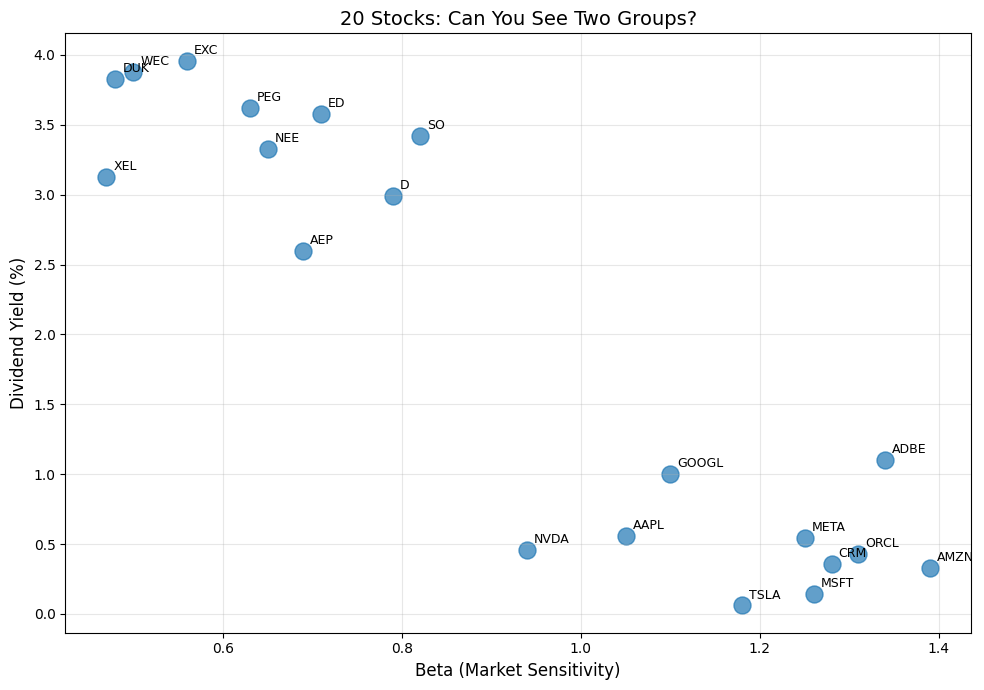

Look at the plot. Do you see a pattern?
Some stocks cluster in the lower-left, others in the upper-right...


In [3]:
# Visualize: just the data, no labels
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(stock_df["beta"], stock_df["dividend_yield"], s=150, alpha=0.7)

for _, row in stock_df.iterrows():                    # Label each point
    ax.annotate(row["ticker"], (row["beta"], row["dividend_yield"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Beta (Market Sensitivity)", fontsize=12)
ax.set_ylabel("Dividend Yield (%)", fontsize=12)
ax.set_title("20 Stocks: Can You See Two Groups?", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Look at the plot. Do you see a pattern?")
print("Some stocks cluster in the lower-left, others in the upper-right...")

### K-Means Algorithm

K-Means finds groups by:
1. Pick K random points as initial "centers"
2. Assign each stock to its nearest center
3. Recalculate centers as the average of each group
4. Repeat until stable

**Important:** Always standardize features first. K-Means uses distance, so features on different scales would dominate.

In [4]:
# Standardize features (mean=0, std=1)
features = ["beta", "dividend_yield"]
X = stock_df[features].values                         # Raw data

scaler = StandardScaler()                             # Create scaler
X_scaled = scaler.fit_transform(X)                    # Fit and transform

print("Before standardization:")
print(f"  Beta range: {X[:, 0].min():.2f} to {X[:, 0].max():.2f}")
print(f"  Dividend range: {X[:, 1].min():.2f} to {X[:, 1].max():.2f}")
print("\nAfter standardization:")
print(f"  Beta range: {X_scaled[:, 0].min():.2f} to {X_scaled[:, 0].max():.2f}")
print(f"  Dividend range: {X_scaled[:, 1].min():.2f} to {X_scaled[:, 1].max():.2f}")

Before standardization:
  Beta range: 0.47 to 1.39
  Dividend range: 0.06 to 3.96

After standardization:
  Beta range: -1.42 to 1.48
  Dividend range: -1.26 to 1.32


In [5]:
# Fit K-Means with K=2 clusters
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X_scaled)                                  # Fit on standardized data

# Add cluster labels to our data
stock_df["cluster"] = kmeans.labels_

print("Cluster assignments:")
print(stock_df[["ticker", "beta", "dividend_yield", "cluster"]])

Cluster assignments:
   ticker  beta  dividend_yield  cluster
0    AAPL  1.05            0.56        0
1    MSFT  1.26            0.14        0
2    NVDA  0.94            0.46        0
3   GOOGL  1.10            1.00        0
4    AMZN  1.39            0.33        0
5    META  1.25            0.54        0
6    TSLA  1.18            0.06        0
7    ADBE  1.34            1.10        0
8     CRM  1.28            0.36        0
9    ORCL  1.31            0.43        0
10    DUK  0.48            3.83        1
11     SO  0.82            3.42        1
12    NEE  0.65            3.33        1
13    AEP  0.69            2.60        1
14    EXC  0.56            3.96        1
15      D  0.79            2.99        1
16     ED  0.71            3.58        1
17    WEC  0.50            3.88        1
18    XEL  0.47            3.13        1
19    PEG  0.63            3.62        1


C:\Users\yulon\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\yulon\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 217, in _count_physical_cores
    raise ValueError(


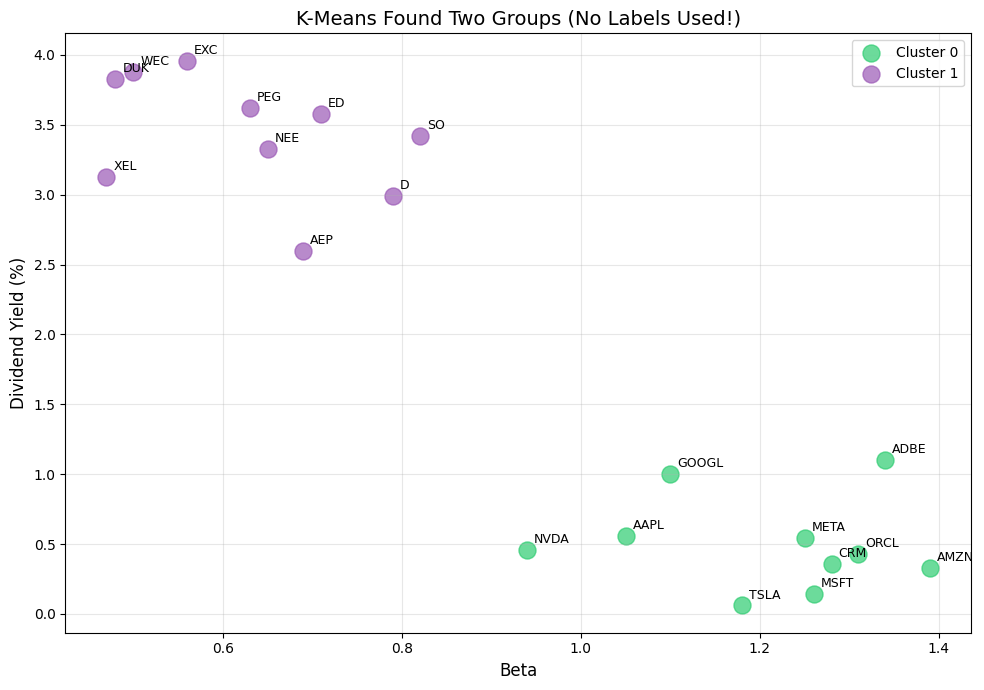

In [6]:
# Visualize the clusters K-Means found
fig, ax = plt.subplots(figsize=(10, 7))

colors = ["#2ecc71", "#9b59b6"]                       # Green and purple
for cluster in [0, 1]:
    mask = stock_df["cluster"] == cluster
    ax.scatter(
        stock_df.loc[mask, "beta"],
        stock_df.loc[mask, "dividend_yield"],
        c=colors[cluster], s=150, label=f"Cluster {cluster}", alpha=0.7
    )

for _, row in stock_df.iterrows():
    ax.annotate(row["ticker"], (row["beta"], row["dividend_yield"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Beta", fontsize=12)
ax.set_ylabel("Dividend Yield (%)", fontsize=12)
ax.set_title("K-Means Found Two Groups (No Labels Used!)", fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### The Reveal: What Did K-Means Find?

Let's check what these clusters actually represent. Our data has a "sector" column we haven't looked at yet...

In [7]:
# What sectors are in each cluster?
print("Cluster composition:")
for cluster in [0, 1]:
    cluster_stocks = stock_df[stock_df["cluster"] == cluster]
    sectors = cluster_stocks["sector"].value_counts()
    print(f"\nCluster {cluster}:")
    for sector, count in sectors.items():
        print(f"  {sector}: {count} stocks")

Cluster composition:

Cluster 0:
  Tech: 10 stocks

Cluster 1:
  Utilities: 10 stocks


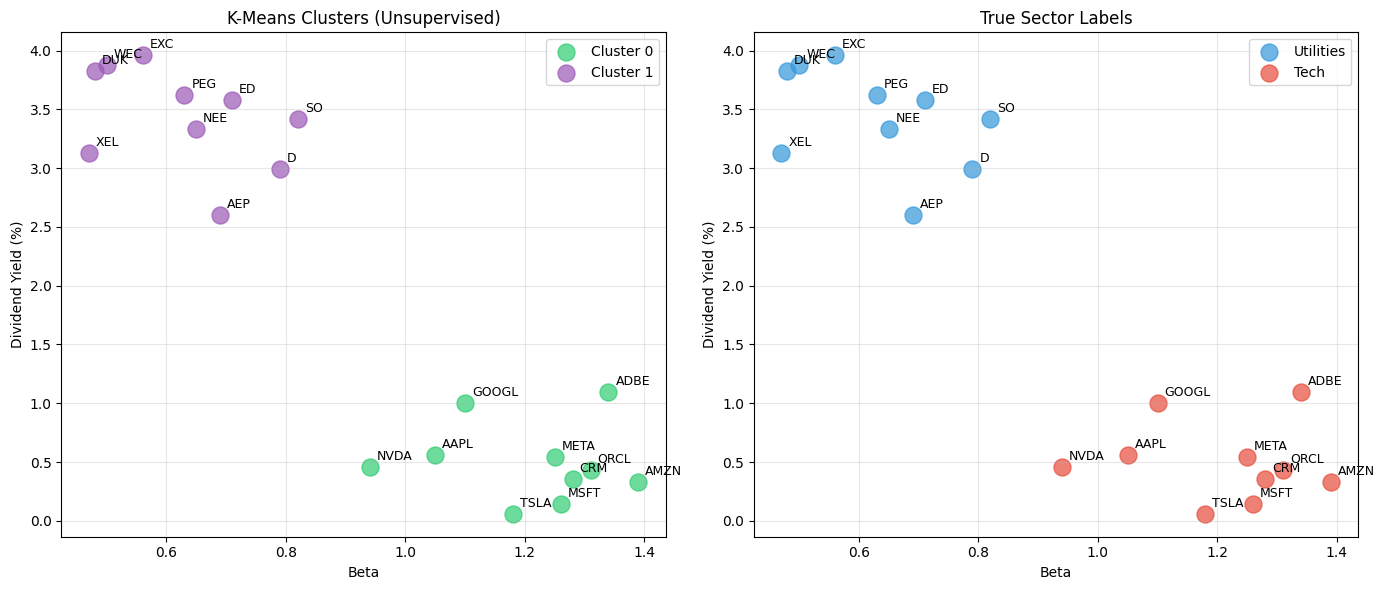

K-Means recovered the sector groupings almost perfectly — with no labels!
It found that Utilities (low beta, high dividend) cluster separately from Tech (high beta, low dividend).


In [8]:
# Side by side: K-Means clusters vs True sectors
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: K-Means clusters
for cluster in [0, 1]:
    mask = stock_df["cluster"] == cluster
    axes[0].scatter(
        stock_df.loc[mask, "beta"],
        stock_df.loc[mask, "dividend_yield"],
        c=colors[cluster], s=150, label=f"Cluster {cluster}", alpha=0.7
    )
for _, row in stock_df.iterrows():
    axes[0].annotate(row["ticker"], (row["beta"], row["dividend_yield"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[0].set_xlabel("Beta")
axes[0].set_ylabel("Dividend Yield (%)")
axes[0].set_title("K-Means Clusters (Unsupervised)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: True sectors
sector_colors = {"Utilities": "#3498db", "Tech": "#e74c3c"}
for sector, color in sector_colors.items():
    mask = stock_df["sector"] == sector
    axes[1].scatter(
        stock_df.loc[mask, "beta"],
        stock_df.loc[mask, "dividend_yield"],
        c=color, s=150, label=sector, alpha=0.7
    )
for _, row in stock_df.iterrows():
    axes[1].annotate(row["ticker"], (row["beta"], row["dividend_yield"]),
                     xytext=(5, 5), textcoords="offset points", fontsize=9)
axes[1].set_xlabel("Beta")
axes[1].set_ylabel("Dividend Yield (%)")
axes[1].set_title("True Sector Labels")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("K-Means recovered the sector groupings almost perfectly — with no labels!")
print("It found that Utilities (low beta, high dividend) cluster separately from Tech (high beta, low dividend).")

### ✏️ Checkpoint: Try K=3 Clusters

What happens if we ask for 3 clusters instead of 2? Does it find a meaningful third group?

Cluster assignments with K=3:
   ticker     sector  beta  dividend_yield  cluster_k3
0    AAPL       Tech  1.05            0.56           0
2    NVDA       Tech  0.94            0.46           0
3   GOOGL       Tech  1.10            1.00           0
17    WEC  Utilities  0.50            3.88           1
16     ED  Utilities  0.71            3.58           1
15      D  Utilities  0.79            2.99           1
14    EXC  Utilities  0.56            3.96           1
13    AEP  Utilities  0.69            2.60           1
12    NEE  Utilities  0.65            3.33           1
11     SO  Utilities  0.82            3.42           1
19    PEG  Utilities  0.63            3.62           1
18    XEL  Utilities  0.47            3.13           1
10    DUK  Utilities  0.48            3.83           1
8     CRM       Tech  1.28            0.36           2
7    ADBE       Tech  1.34            1.10           2
6    TSLA       Tech  1.18            0.06           2
5    META       Tech  1.25         

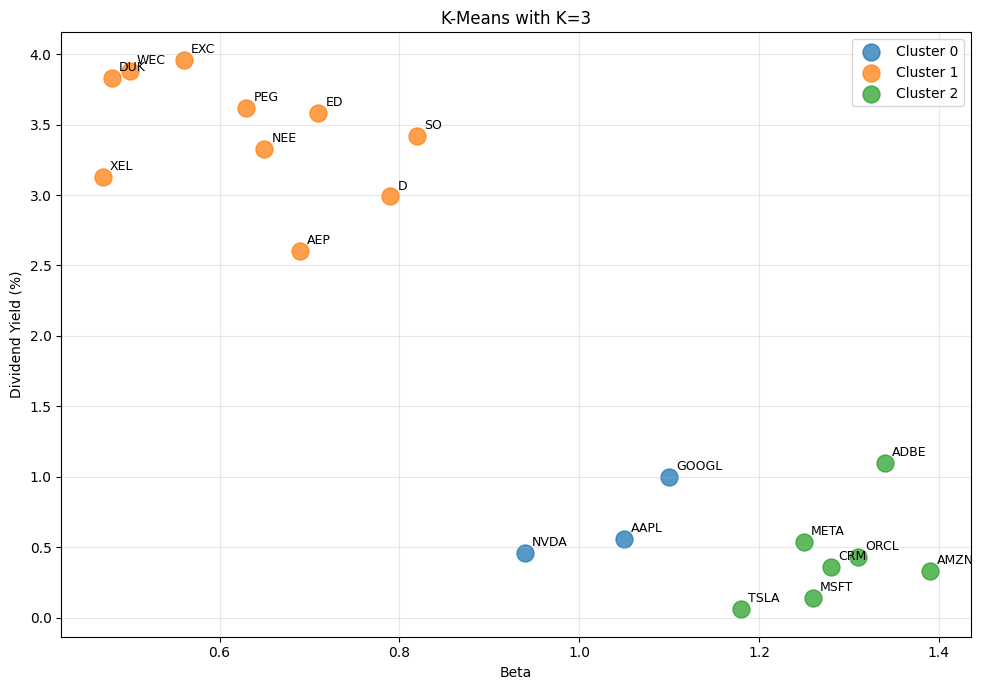

K=3 keeps most Tech and Utilities separated, then splits one side into a smaller subgroup.


In [9]:
# Try K-Means with K=3 clusters
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_k3.fit(X_scaled)

stock_df["cluster_k3"] = kmeans_k3.labels_
print("Cluster assignments with K=3:")
print(stock_df[["ticker", "sector", "beta", "dividend_yield", "cluster_k3"]].sort_values("cluster_k3"))

fig, ax = plt.subplots(figsize=(10, 7))
for cluster in sorted(stock_df["cluster_k3"].unique()):
    mask = stock_df["cluster_k3"] == cluster
    ax.scatter(
        stock_df.loc[mask, "beta"],
        stock_df.loc[mask, "dividend_yield"],
        s=150,
        label=f"Cluster {cluster}",
        alpha=0.75,
    )

for _, row in stock_df.iterrows():
    ax.annotate(row["ticker"], (row["beta"], row["dividend_yield"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9)

ax.set_xlabel("Beta")
ax.set_ylabel("Dividend Yield (%)")
ax.set_title("K-Means with K=3")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("K=3 keeps most Tech and Utilities separated, then splits one side into a smaller subgroup.")


---

## 2. Random Forest Classification

### A Different Question

In Module 3, we tried to predict the *exact* return. That's hard — R² is basically zero.

But what if we ask an easier question: **Will the stock go UP or DOWN tomorrow?**

This is **classification** instead of regression. Instead of predicting a number, we predict a category.

And instead of R², we measure **accuracy**: what percentage of days did we get right? If we're just guessing, we'd expect 50%. Can we beat that?

We'll use features from our dataset:
- **Basic**: today's return, volume change, price range, overnight gap
- **Technical**: 20-day volatility, 5-day momentum
- **Market**: S&P 500 return, VIX level

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Load and prepare stock data with features
df = pd.read_csv("data/stock_prices.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# Calculate returns within each ticker
df["return"] = df.groupby("ticker")["adj_close"].pct_change()

# Feature engineering (computed within each ticker group)
df["volume_chg"] = df.groupby("ticker")["volume"].pct_change()
df["range_pct"] = (df["high"] - df["low"]) / df["adj_close"]
df["gap"] = (df["open"] - df.groupby("ticker")["adj_close"].shift(1)) / df.groupby("ticker")["adj_close"].shift(1)

# Moving averages and technical features
df["ma5"] = df.groupby("ticker")["adj_close"].transform(lambda x: x.rolling(5).mean())
df["ma20"] = df.groupby("ticker")["adj_close"].transform(lambda x: x.rolling(20).mean())
df["price_vs_ma5"] = (df["adj_close"] - df["ma5"]) / df["ma5"]
df["price_vs_ma20"] = (df["adj_close"] - df["ma20"]) / df["ma20"]

# Volatility and momentum
df["volatility_5d"] = df.groupby("ticker")["return"].transform(lambda x: x.rolling(5).std())
df["volatility_20d"] = df.groupby("ticker")["return"].transform(lambda x: x.rolling(20).std())
df["momentum_5d"] = df.groupby("ticker")["adj_close"].transform(lambda x: x.pct_change(5))
df["momentum_20d"] = df.groupby("ticker")["adj_close"].transform(lambda x: x.pct_change(20))

# Load market data and add SPY return and VIX
market_df = pd.read_csv("data/market_data.csv")
market_df["date"] = pd.to_datetime(market_df["date"])

spy = market_df[market_df["ticker"] == "SPY"][["date", "close_px"]].rename(columns={"close_px": "spy_close"})
spy["spy_return"] = spy["spy_close"].pct_change()
vix = market_df[market_df["ticker"] == "VIX"][["date", "close_px"]].rename(columns={"close_px": "vix"})

df = df.merge(spy[["date", "spy_return"]], on="date", how="left")
df = df.merge(vix[["date", "vix"]], on="date", how="left")

print(f"Loaded {len(df):,} rows")
print(f"Tickers: {df['ticker'].unique().tolist()}")

# Show available features
print(f"\nFeatures available:")
print(df.columns.tolist())

Loaded 26,060 rows
Tickers: ['AAPL', 'ADBE', 'AEP', 'AMZN', 'CRM', 'D', 'DUK', 'ED', 'EXC', 'GOOGL', 'META', 'MSFT', 'NEE', 'NVDA', 'ORCL', 'PEG', 'SO', 'TSLA', 'WEC', 'XEL']

Features available:
['date', 'ticker', 'open', 'high', 'low', 'adj_close', 'volume', 'return', 'volume_chg', 'range_pct', 'gap', 'ma5', 'ma20', 'price_vs_ma5', 'price_vs_ma20', 'volatility_5d', 'volatility_20d', 'momentum_5d', 'momentum_20d', 'spy_return', 'vix']


In [11]:
# Focus on AAPL
aapl = df[df["ticker"] == "AAPL"].copy().set_index("date")

# Target: will tomorrow go UP (1) or DOWN (0)?
aapl["tomorrow_return"] = aapl["return"].shift(-1)
aapl["direction"] = (aapl["tomorrow_return"] > 0).astype(int)

# Features we'll use
features = [
    # Basic (things we observe today)
    "return", "volume_chg", "range_pct", "gap",
    # Technical
    "volatility_20d", "momentum_5d",
    # Market
    "spy_return", "vix",
]

# Prepare data (drop rows with missing values)
class_data = aapl[features + ["direction"]].dropna()
split_idx = int(len(class_data) * 0.8)

train = class_data.iloc[:split_idx]
test = class_data.iloc[split_idx:]

X_train = train[features].values
y_train = train["direction"].values
X_test = test[features].values
y_test = test["direction"].values

print(f"Using {len(features)} features:")
for f in features:
    print(f"  • {f}")
print(f"\nTraining: {len(train)} days")
print(f"Testing:  {len(test)} days")
print(f"\nClass balance in test data:")
print(f"  Up days:   {y_test.sum()} ({y_test.mean():.1%})")
print(f"  Down days: {len(y_test) - y_test.sum()} ({1 - y_test.mean():.1%})")

Using 8 features:
  • return
  • volume_chg
  • range_pct
  • gap
  • volatility_20d
  • momentum_5d
  • spy_return
  • vix

Training: 1026 days
Testing:  257 days

Class balance in test data:
  Up days:   129 (50.2%)
  Down days: 128 (49.8%)


### What is Random Forest?

A Random Forest is a collection of decision trees. Each tree learns simple rules like:
- "If volatility > 0.02 AND momentum < 0, predict DOWN"
- "If volume is high AND price is above MA, predict UP"

The "forest" part: instead of one tree, we build many trees (100 by default), each trained on a random subset of the data and features. The final prediction is a **vote** — whatever most trees predict wins.

Why this works:
- Individual trees might overfit, but averaging many trees reduces noise
- Different trees focus on different patterns
- It's robust and hard to break

In [12]:
# Fit Random Forest
rf = RandomForestClassifier(n_estimators=1000, max_depth=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Accuracy
acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print("=" * 50)
print("RANDOM FOREST: Predicting UP or DOWN")
print("=" * 50)
print(f"Training accuracy: {acc_train:.1%}")
print(f"Test accuracy:     {acc_test:.1%}")
print(f"")
print(f"Baseline (random guessing): 50%")
print(f"Improvement over baseline:  {acc_test - 0.5:+.1%}")

RANDOM FOREST: Predicting UP or DOWN
Training accuracy: 100.0%
Test accuracy:     51.4%

Baseline (random guessing): 50%
Improvement over baseline:  +1.4%


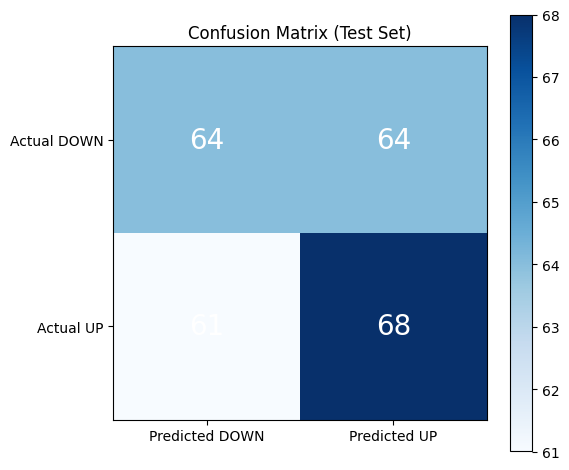

Reading the matrix:
  Correctly predicted DOWN: 64 days
  Correctly predicted UP:   68 days
  Wrong (predicted UP, was DOWN):   64 days
  Wrong (predicted DOWN, was UP):   61 days


In [13]:
# Confusion matrix: where did we get it right/wrong?
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted DOWN", "Predicted UP"])
ax.set_yticklabels(["Actual DOWN", "Actual UP"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=20,
                color="white" if cm[i, j] > cm.max()/2 else "black")

ax.set_title("Confusion Matrix (Test Set)")
plt.colorbar(im)
plt.tight_layout()
plt.show()

print("Reading the matrix:")
print(f"  Correctly predicted DOWN: {cm[0,0]} days")
print(f"  Correctly predicted UP:   {cm[1,1]} days")
print(f"  Wrong (predicted UP, was DOWN):   {cm[0,1]} days")
print(f"  Wrong (predicted DOWN, was UP):   {cm[1,0]} days")

### Feature Importance: What Does the Model Care About?

One of the best things about Random Forest: it tells you **which features matter most**.

The importance score measures how much each feature helps the trees make better splits. Higher = more important.

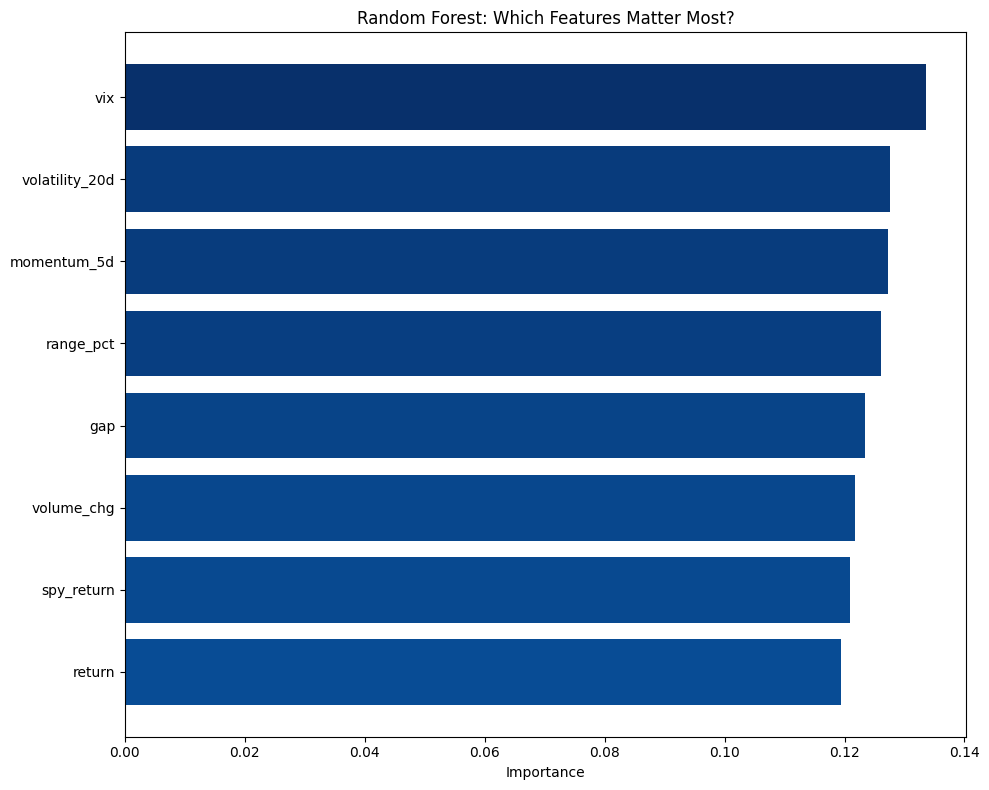

Most important features:
  vix: 0.134
  volatility_20d: 0.128
  momentum_5d: 0.127
  range_pct: 0.126
  gap: 0.123


In [14]:
# Feature importance
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.Blues(importance_df["importance"] / importance_df["importance"].max())
ax.barh(importance_df["feature"], importance_df["importance"], color=colors)
ax.set_xlabel("Importance")
ax.set_title("Random Forest: Which Features Matter Most?")
plt.tight_layout()
plt.show()

# Top features
print("Most important features:")
for _, row in importance_df.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")

### The Takeaway

We achieved a small improvement over random guessing (50%).

That might sound disappointing, but consider:
- **Stock returns are hard to predict.** This is a fundamental result in finance.
- **Even small edges matter.** A few percent edge, applied consistently over thousands of trades, can be meaningful.
- **The model learned something real.** Look at the feature importance — it's telling us which signals have predictive power.

What's interesting about the feature importance:
- **Momentum features** often rank highly — recent trends have some predictive power
- **Volatility** measures how "noisy" the stock is
- **Volume changes** can signal unusual activity

The honest truth: you're not going to get rich from a simple model like this. But you now understand how practitioners approach prediction problems in finance.

### ✏️ Checkpoint: Tune the Forest

Try changing these Random Forest parameters and see how accuracy changes:
- `n_estimators`: Number of trees (default 100). More trees = more stable but slower.
- `max_depth`: How deep each tree can go (default None = unlimited). Shallower = less overfitting.

In [15]:
# Tune the Random Forest by using fewer, shallower trees
tuned_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42,
)
tuned_rf.fit(X_train, y_train)

train_pred_tuned = tuned_rf.predict(X_train)
test_pred_tuned = tuned_rf.predict(X_test)

acc_train_tuned = accuracy_score(y_train, train_pred_tuned)
acc_test_tuned = accuracy_score(y_test, test_pred_tuned)

print("TUNED RANDOM FOREST")
print(f"Training accuracy: {acc_train_tuned:.1%}")
print(f"Test accuracy:     {acc_test_tuned:.1%}")
print(f"Original test accuracy: {acc_test:.1%}")
print(f"Change in test accuracy: {acc_test_tuned - acc_test:+.1%}")


TUNED RANDOM FOREST
Training accuracy: 71.6%
Test accuracy:     51.4%
Original test accuracy: 51.4%
Change in test accuracy: +0.0%


---

## 3. Exercises

Complete these to finish Module 4.

### Exercise 4.1: Elbow Method

How do we choose K for K-Means? One way: plot the "inertia" (within-cluster sum of squares) for K=1,2,3,...,6. Look for an "elbow" where adding more clusters stops helping much.

```python
inertias = []
for k in range(1, 7):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.plot(range(1, 7), inertias, marker='o')
```

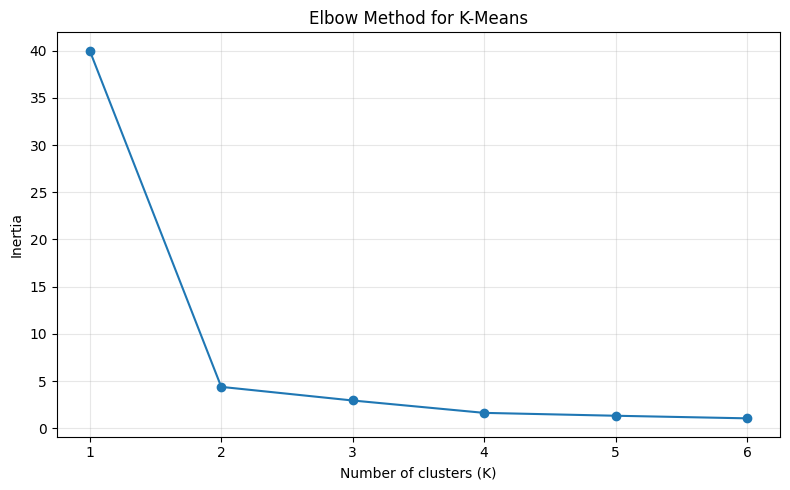

K=1: inertia=40.00
K=2: inertia=4.38
K=3: inertia=2.94
K=4: inertia=1.63
K=5: inertia=1.32
K=6: inertia=1.05
The biggest improvement happens by K=2, matching the Tech vs Utilities structure.


In [16]:
# Exercise 4.1: Elbow method for K-Means
inertias = []
k_values = range(1, 7)

for k in k_values:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, 7), inertias, marker="o")
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method for K-Means")
ax.set_xticks(list(k_values))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, inertia in zip(k_values, inertias):
    print(f"K={k}: inertia={inertia:.2f}")

print("The biggest improvement happens by K=2, matching the Tech vs Utilities structure.")


### Exercise 4.2: Try a Different Stock

Does Random Forest work better or worse on different stocks? Try running the classification on NVDA or MSFT instead of AAPL.

```python
# Change the ticker and re-run the classification
ticker = "NVDA"  # or "MSFT", "GOOGL", etc.
stock = df[df["ticker"] == ticker].copy().set_index("date")
# ... (same feature engineering as before)
```

Does the accuracy change? Does the feature importance change?

In [17]:
# Exercise 4.2: Try Random Forest on a different stock
ticker = "NVDA"
stock = df[df["ticker"] == ticker].copy().set_index("date")

stock["tomorrow_return"] = stock["return"].shift(-1)
stock["direction"] = (stock["tomorrow_return"] > 0).astype(int)

stock_class_data = stock[features + ["direction"]].dropna()
stock_split_idx = int(len(stock_class_data) * 0.8)
stock_train = stock_class_data.iloc[:stock_split_idx]
stock_test = stock_class_data.iloc[stock_split_idx:]

X_train_stock = stock_train[features].values
y_train_stock = stock_train["direction"].values
X_test_stock = stock_test[features].values
y_test_stock = stock_test["direction"].values

rf_stock = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=8,
    random_state=42,
)
rf_stock.fit(X_train_stock, y_train_stock)

stock_pred_train = rf_stock.predict(X_train_stock)
stock_pred_test = rf_stock.predict(X_test_stock)
acc_train_stock = accuracy_score(y_train_stock, stock_pred_train)
acc_test_stock = accuracy_score(y_test_stock, stock_pred_test)

print(f"{ticker} Random Forest")
print(f"Training accuracy: {acc_train_stock:.1%}")
print(f"Test accuracy:     {acc_test_stock:.1%}")
print(f"AAPL test accuracy: {acc_test:.1%}")
print(f"Difference vs AAPL: {acc_test_stock - acc_test:+.1%}")

importance_stock = pd.DataFrame({
    "feature": features,
    "importance": rf_stock.feature_importances_,
}).sort_values("importance", ascending=False)

print()
print("Top NVDA features:")
for _, row in importance_stock.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.3f}")


NVDA Random Forest
Training accuracy: 77.5%
Test accuracy:     55.6%
AAPL test accuracy: 51.4%
Difference vs AAPL: +4.3%

Top NVDA features:
  return: 0.152
  range_pct: 0.144
  momentum_5d: 0.141
  volume_chg: 0.121
  vix: 0.116


### Exercise 4.3: Commit Your Work

```bash
git add .
git commit -m "Complete module 4 exercises"
git push
```

---

## Recap

| Technique | Use When | Key Method |
|-----------|----------|------------|
| **K-Means** | Find groups without labels | `KMeans(n_clusters=K).fit(X)` |
| **Random Forest** | Predict categories, understand feature importance | `RandomForestClassifier().fit(X, y)` |

### Key Takeaways

1. **K-Means discovers structure** — it found industry groupings from just beta and dividend yield
2. **Always standardize** before K-Means (it uses distance)
3. **Classification reframes the problem** — "up or down?" is easier to interpret than "what's the return?"
4. **Feature importance** shows what the model learned
5. **Out-of-sample evaluation is essential** — train accuracy can lie, test accuracy tells the truth
6. **Small edges matter in finance** — even a few percent above 50% is meaningful at scale

---

**Next up:** Module 5 — Responsible Coding with AI. We'll build a project from scratch using AI assistance.